[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EelcoHoogendoorn/numga/blob/rewrite/rewrite/examples/geometry/multiview/multiview_reconstruction.ipynb) [![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/EelcoHoogendoorn/numga?ref=rewrite)

# Multi-View Scene Reconstruction & Camera Alignment in PGA2D

When multiple cameras observe a scene, our goal is to jointly reconstruct scene points and align camera poses.

Rather than shuffling coordinate matrices and ray-intersection heuristics, this notebook uses **extensors** (linear maps between blade subspaces):
sensor pixels lift into perspective sight cones, directional constraints from multiple cameras fuse by simple addition into confidence ellipses (Gaussian splats), point centers are the poles of the line at infinity under the fused quadric, and camera poses follow from Newton's method on the cone value itself.


In [1]:
# Setup environment: clone repository and install dependencies if running in Colab
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import os, shutil, subprocess
    os.chdir("/content")  # Always reset to /content
    repo_dir = Path("/content/numga_repo")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "-b", "rewrite", "https://github.com/EelcoHoogendoorn/numga.git", str(repo_dir)], check=True)
    else:
        subprocess.run(["git", "-C", str(repo_dir), "pull", "origin", "rewrite"], check=False)
    rewrite_dir = repo_dir / "rewrite"
    src_dir = rewrite_dir / "src"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "imageio"], check=True)
    for p in [str(src_dir), str(rewrite_dir)]:
        if p not in sys.path:
            sys.path.insert(0, p)

# Ensure rewrite root is in sys.path when running locally:
for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / "examples" / "geometry" / "multiview").is_dir():
        if str(cand) not in sys.path:
            sys.path.insert(0, str(cand))
        break
    if (cand / "rewrite" / "examples" / "geometry" / "multiview").is_dir():
        p = str(cand / "rewrite")
        if p not in sys.path:
            sys.path.insert(0, p)
        break

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np

from numga import stack
from numga.algebras import PGA2D
from examples import instantiate
from examples.animation import save_animation
from examples.geometry.multiview import render

# The multiview mathematics is written for any PGA; this notebook works in the plane.
core = instantiate("examples.geometry.multiview.core", PGA2D)
Camera = core.Camera            # Projective transformation extensor: Point <- Point
Motor = core.Motor              # Even-grade multivector: rigid planar motions in SE(2)
Plane = core.Plane              # Grade-1 multivector: lines in 2D / planes in 3D (a*x + b*y + c*w = 0)
Point = core.Point              # Grade-2 multivector: 2D points [x, y, w]
Quadric = core.Quadric          # A quadric as a polarity map: a point's polar line, Plane <- Point
Scalar = core.Scalar            # Grade-0 multivector: scalar values
Twist = core.Twist              # Lie algebra se(2) generator for infinitesimal twists
Information = core.Information  # Curvature of the cost over pose twists: Scalar <- (Twist, Twist)
mv = core.mv                    # Basis multivector generator (mv.x, mv.y, mv.w, mv.xy, mv.xw, mv.yw)
point = core.point              # Algebraic constructor: converts NumPy arrays to typed Point multivectors
w = core.w                      # The ideal line/plane at infinity: mv.w

## 1. Setup Scene and 3-Camera Rig

We place 6 ground truth scene points in front of a convergent 3-camera rig (left, center, and right viewpoints).

In standard GA, projecting a point joins it with the pinhole origin `c0` and meets it with the sensor line `screen`: `(c0 & p) ^ screen`. In numga, leaving the operand unbound as the type `Point` compiles directly into an **Extensor**—a compiled linear map between blade subspaces (`Point <- Point`).


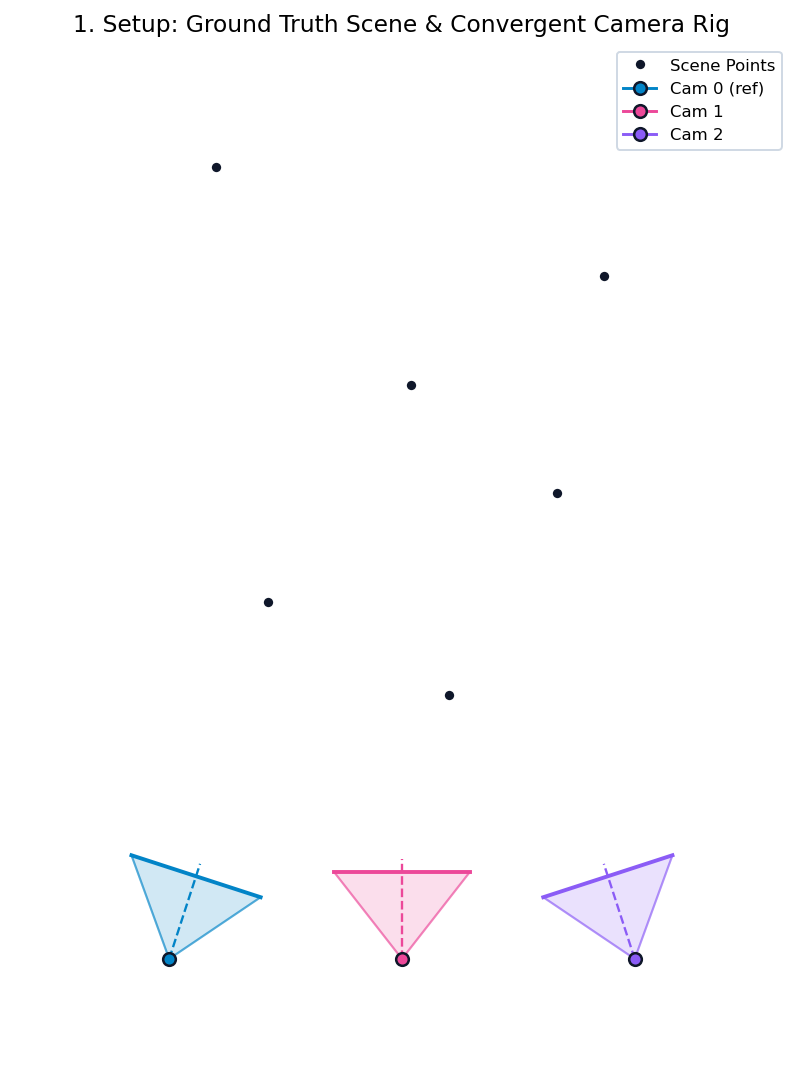

In [3]:
# 1. Define 6 ground truth scene points in front of the cameras:
coords = np.array([
    [ 0.15, 0.85],
    [-0.43, 1.15],
    [ 0.50, 1.50],
    [ 0.03, 1.85],
    [ 0.65, 2.20],
    [-0.60, 2.55],
])
true_points = point(coords)                         # [n_points] Point

# 2. Construct 3 convergent camera poses (left, center, right):
xs = np.array([-0.75, 0.0, 0.75])
thetas = np.radians([18.0, 0.0, -18.0])
true_poses = ((mv.xw * xs) * 0.5).exp() * ((mv.xy * thetas) * 0.5).exp()  # [n_cams] Motor

# 3. Construct projective camera model (Point <- Point):
c0 = point([0.0, 0.0])                              # Point (pinhole origin)
screen = mv.y - mv.w                                # Line (sensor line y = 1)
projection = (c0 & Point) ^ screen                  # PointMap: Point <- Point

# Plot 1: Setup - Ground truth scene points and convergent camera rig
fig = render.draw_rig(true_poses, true_points)
plt.title("1. Setup: Ground Truth Scene & Convergent Camera Rig")
plt.show()

## 2. Sensor Pixel Measurements & Perspective Sight Cones

Projecting scene points produces 1D transverse pixel measurements on the sensor lines. Each measurement is a rank-1 precision disc, a quadric on sensor points written as a polarity map: it sends a point to its polar line, and the quadric's value at a point is the join of that polar with the point, `disc(p) & p`. The plane comes first in that join by convention, since the regressive product of a line and a point changes sign with the dimension.

Feeding the camera into the disc and carrying its polar lines back through the camera lifts the disc into a 2D perspective sight cone on scene points. The carrying map is the map on lines induced by the camera, solved from the incidence pairing; it exists although the camera is singular.


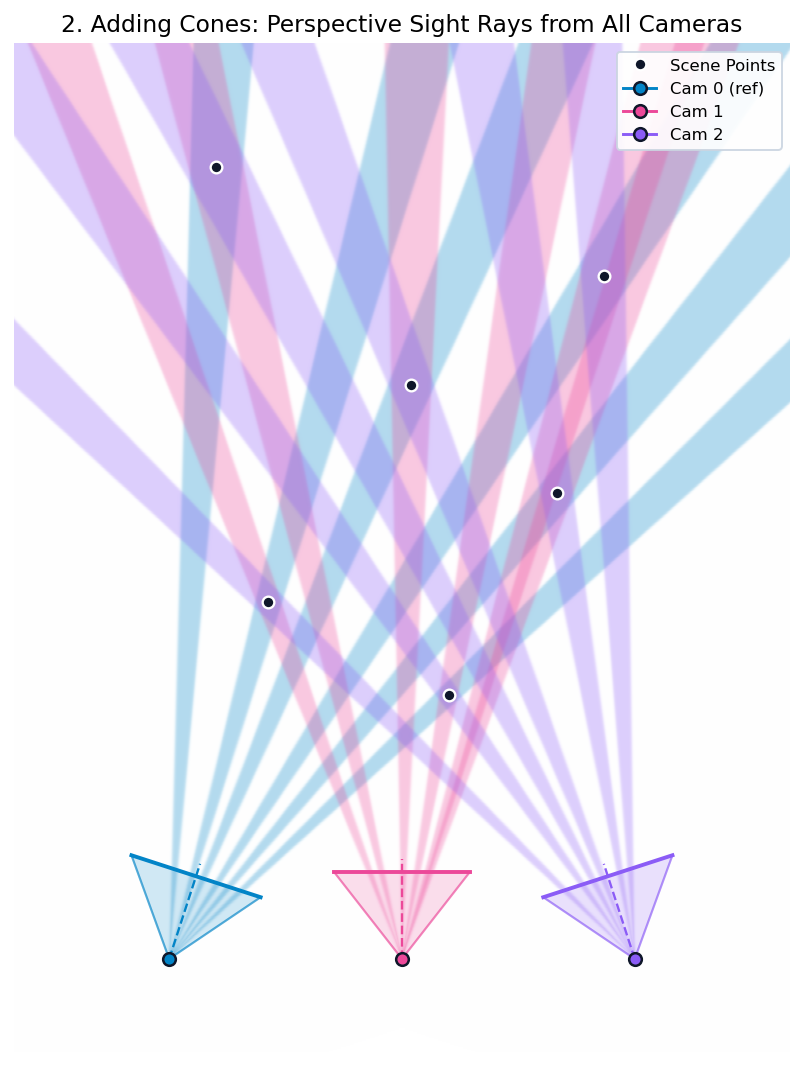

In [4]:
# 1. Project scene points into cameras: compute perspective projection and homogeneous pixel positions:
local_points = true_poses << true_points[:, None]   # [n_points, n_cams] Point
projs = projection(local_points)                    # [n_points, n_cams] Point
pixels = projs / (mv.w & projs)                     # [n_points, n_cams] Point (homogeneous coordinates)

# 2. Measure pixel precision on the sensor plane: at each measured pixel, transverse uncertainty
#    is the dyad of the transverse normal line with its own readout, normal * (normal & Point):
normal = mv.x - mv.w * (mv.x & pixels)              # [n_points, n_cams] Plane (transverse normal lines)
sensor_discs = normal * (normal & Point)            # [n_points, n_cams] Plane <- Point (sensor precision discs)

# 3. The map on lines induced by the camera, solved from the incidence pairing Plane & Point:
#    it satisfies on_lines(l) & p == l & projection(p) for every line l and point p:
on_lines = (Plane & Point).solve(Plane & projection)   # [] Plane <- Plane

# 4. Lift sensor pixels into sight cones: feed the projection into the disc and carry its polar
#    lines back through the camera. The cone is a quadric on scene points that widens with depth:
cones = on_lines(sensor_discs(projection))          # [n_points, n_cams] Plane <- Point (sight cones)

# 5. Move sight cones into world space like any map: pull the input point into the camera's frame,
#    push the output line out to the world:
world_cones = true_poses >> cones(true_poses << Point)   # [n_points, n_cams] Plane <- Point

# Plot 2: Adding Cones - Perspective sight rays fanning out through scene points
fig = render.draw_cones(true_poses, world_cones, true_points)
plt.title("2. Adding Cones: Perspective Sight Rays from All Cameras")
plt.show()


## 3. Closed-Form Point Reconstruction & Pre-Optimization Geometry

Summing sight cones across all cameras fuses directional constraints into localized confidence ellipses (Gaussian splats). The fused cone's polar of its own vertex vanishes. Adding a gauge dyad on the weight, `w * (w & Point)`, turns that null direction into the pole of the line at infinity, so the point is `splats.solve(w)` in closed form.

Below, we perturb Camera 2 to introduce pose error and reconstruct the initial splats.


Pre-optimization point RMSE (Cam 2 perturbed): 0.112666 m (11.27 cm)


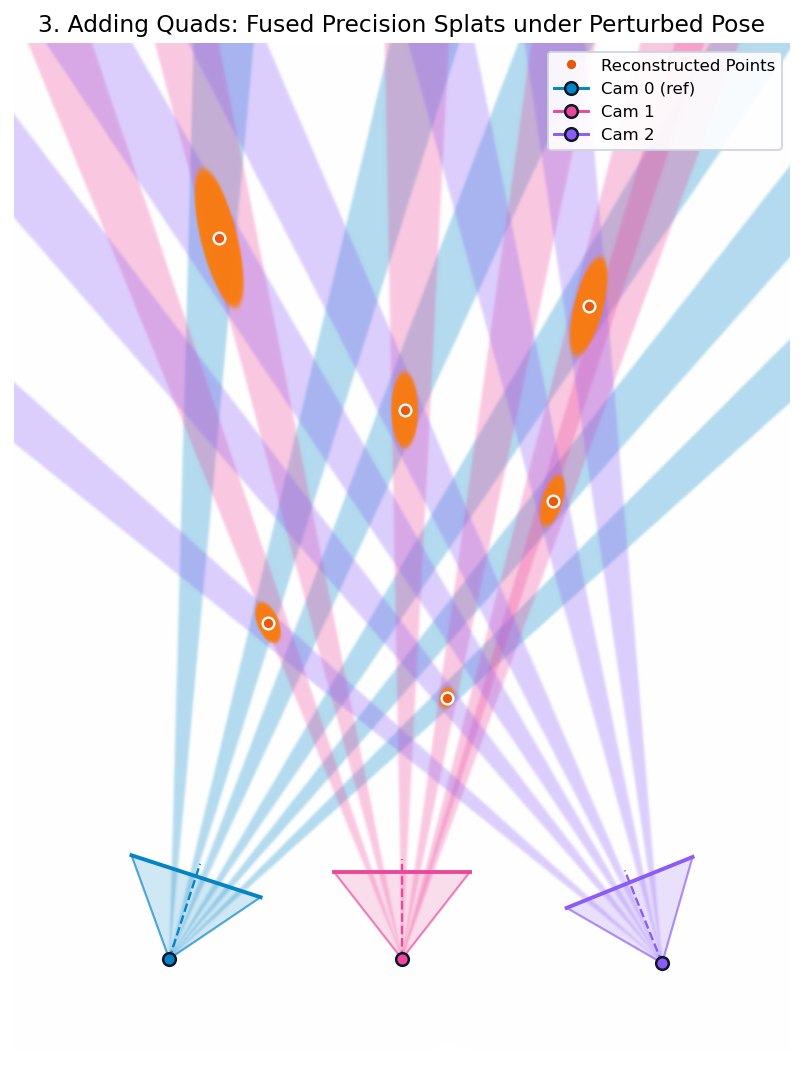

In [5]:
def triangulate_cones(poses: Motor, cones: Quadric) -> tuple[Point, Quadric]:
    """Triangulate scene points as the vertices of fused sight cone quadrics."""
    # 1. Move sight cones to world space: pull the point into each camera's frame, push the polar line out:
    world_cones = poses >> cones(poses << Point)                # [n_points, n_cams] Plane <- Point

    # 2. Fuse sight cones across all cameras: quadratic constraints add into confidence ellipsoids (splats):
    splats = world_cones.sum(axis=-1)                           # [n_points] Plane <- Point

    # 3. The fused cone's polar of its vertex vanishes. The gauge dyad on the weight makes that
    #    vertex the pole of the line at infinity, so the point solves splats(x) = w:
    points = (splats + w * (w & Point)).solve(w).normalized()   # [n_points] Point

    return points, splats


# Perturb Camera 2 (right camera): +8 cm x, -4 cm y, -4 deg yaw:
pert2 = ((mv.xw * 0.08 - mv.yw * 0.04) * 0.5).exp() * ((-mv.xy * np.radians(4.0)) * 0.5).exp()
initial_poses = stack([true_poses[0], true_poses[1], true_poses[2] * pert2])  # [n_cams] Motor

# Initial closed-form triangulation and its error. The difference of two unit points is a
# direction; its Euclidean length is the norm of its complement, a line through the origin:
init_points, init_splats = triangulate_cones(initial_poses, cones)
init_error = (init_points - true_points).dual()                                   # [n_points] Plane
init_rmse = init_error.norm_squared().mean(axis=0).square_root()                  # [] Scalar
print(f"Pre-optimization point RMSE (Cam 2 perturbed): {init_rmse.to_array():.6f} m ({(init_rmse * 100).to_array():.2f} cm)")

# Plot 3: Adding Quads - Fused precision splats under perturbed pose
# Move sight cones to world space under perturbed camera poses:
init_world_cones = initial_poses >> cones(initial_poses << Point)
fig = render.draw_reconstruction(initial_poses, init_world_cones, init_splats, init_points)
plt.title("3. Adding Quads: Fused Precision Splats under Perturbed Pose")
plt.show()


## 4. Alternating Camera Alignment

We align camera poses by alternating between closed-form point reconstruction and Newton steps on the cone value:
1. **Reconstruct Points**: `triangulate_cones(poses, cones)`.
2. **Camera Sensitivity**: a small right step of a camera's pose moves its local points by `motion = -Twist.commutator(local_points)`, a map `Point <- Twist`.
3. **Newton on the Cone Value**: the cost is the polar of the point joined with the point, `cones(local_points) & local_points`. The polar of the moved point joined with the motion, `cones(motion) & motion`, is its curvature over twists, and the point's polar joined with the motion, `cones(local_points) & motion`, its gradient. The cone is the cost, so no residual metric is chosen.
4. **Solve & Update**: solve the curvature form against the gradient for the twist step, then `poses = poses * (step * 0.5).exp()`.


Iter  | Point RMSE (m)   | Cone cost   
------------------------------------------
Iteration  1 | Point RMSE: 0.112666 m | cost: 5.598e-03
Iteration  2 | Point RMSE: 0.111828 m | cost: 1.410e-03
Iteration  3 | Point RMSE: 0.111534 m | cost: 3.633e-04
Iteration  4 | Point RMSE: 0.111405 m | cost: 1.010e-04
Iteration  5 | Point RMSE: 0.111331 m | cost: 3.509e-05
Iteration  6 | Point RMSE: 0.111278 m | cost: 1.843e-05
Iteration  7 | Point RMSE: 0.111234 m | cost: 1.414e-05
Iteration  8 | Point RMSE: 0.111194 m | cost: 1.296e-05

Alternating Loop Final Point RMSE: 0.111157 m (11.12 cm)


Saved /Users/eelco/development/hobby/numga/rewrite/plots/multiview_reconstruction_convergence.gif


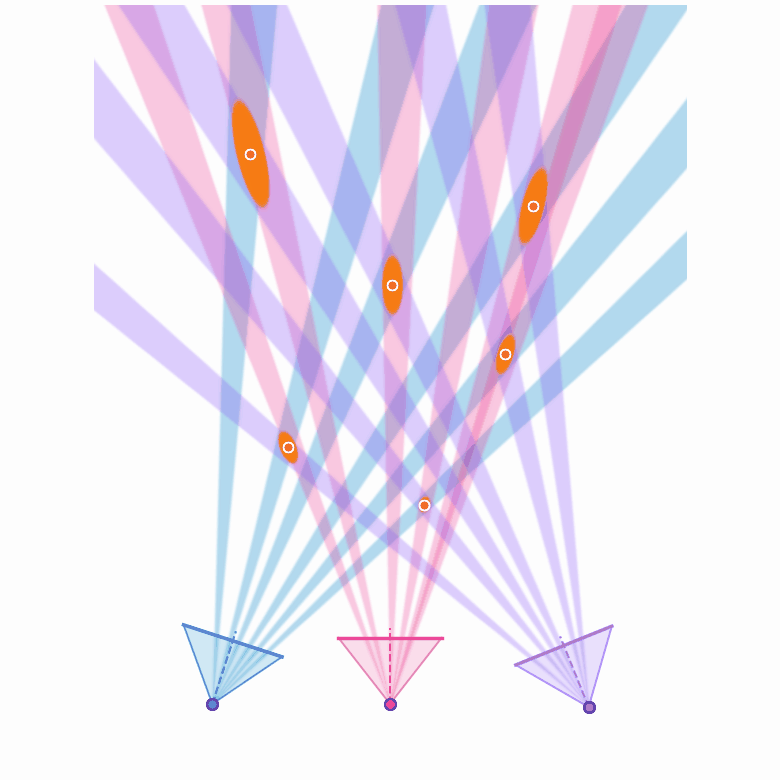

In [6]:
# Alternating Gauss-Newton optimization:
poses = initial_poses                                        # [n_cams] Motor
damping = 0.5
iterations = 8

history = []

print(f"{'Iter':<5} | {'Point RMSE (m)':<16} | {'Cone cost':<12}")
print("-" * 42)

for it in range(iterations):
    # 1. Reconstruct scene points: freeze camera poses and extract the fused cones' vertices:
    points, splats = triangulate_cones(poses, cones)
    history.append((poses, points, splats))

    # 2. View from camera: transform world points into each camera's local frame (motor pullback):
    local_points = poses << points[:, None]                 # [n_points, n_cams] Point (local coordinates)

    # 3. Camera sensitivity: how each local point moves under a small right step of its camera's pose:
    motion = -Twist.commutator(local_points)                # [n_points, n_cams] Point <- Twist

    # 4. Newton on the cone value: the polar of the moved point joined with the motion is the curvature,
    #    the polar of the point joined with the motion the gradient, summed over the points each camera sees:
    curvature = (cones(motion) & motion).sum(axis=0)        # [n_cams] Scalar <- (Twist, Twist)
    gradient = (cones(local_points) & motion).sum(axis=0)   # [n_cams] Scalar <- Twist

    # 5. Solve the curvature form against the gradient for the camera step, and update the poses:
    step = curvature.solve(-gradient)                       # [n_cams] Twist (infinitesimal pose step)
    poses = poses * (step * (0.5 * damping)).exp()          # [n_cams] Motor (updated camera poses)

    cost = (cones(local_points) & local_points).sum()       # [] Scalar: the objective itself
    error = (points - true_points).dual()                   # [n_points] Plane
    current_rmse = error.norm_squared().mean(axis=0).square_root()   # [] Scalar
    print(f"Iteration {it + 1:2d} | Point RMSE: {current_rmse.to_array():.6f} m | cost: {cost.to_array():.3e}")

opt_poses_alt = poses                                       # [n_cams] Motor
opt_points_alt, opt_splats_alt = triangulate_cones(opt_poses_alt, cones)
history.append((opt_poses_alt, opt_points_alt, opt_splats_alt))

alt_error = (opt_points_alt - true_points).dual()                                # [n_points] Plane
alt_rmse = alt_error.norm_squared().mean(axis=0).square_root()                    # [] Scalar
print(f"\nAlternating Loop Final Point RMSE: {alt_rmse.to_array():.6f} m ({(alt_rmse * 100).to_array():.2f} cm)")

# Convergence animation of alternating camera alignment:
frames = render.animate_convergence(
    (poses, poses >> cones(poses << Point), splats, points) for poses, points, splats in history
)
gif_path = save_animation(frames, "multiview_reconstruction_convergence", 333)
display(Image(filename=str(gif_path)))

## 5. Camera Pose Uncertainty & Covariance Geometry

The curvature of the cone cost over a camera's pose twist is the information on that pose (`Scalar <- (Twist, Twist)`). Its inverse on readouts is the pose covariance: the renderer reads 1-sigma positional ellipses for the camera centers and angular heading fans from it.


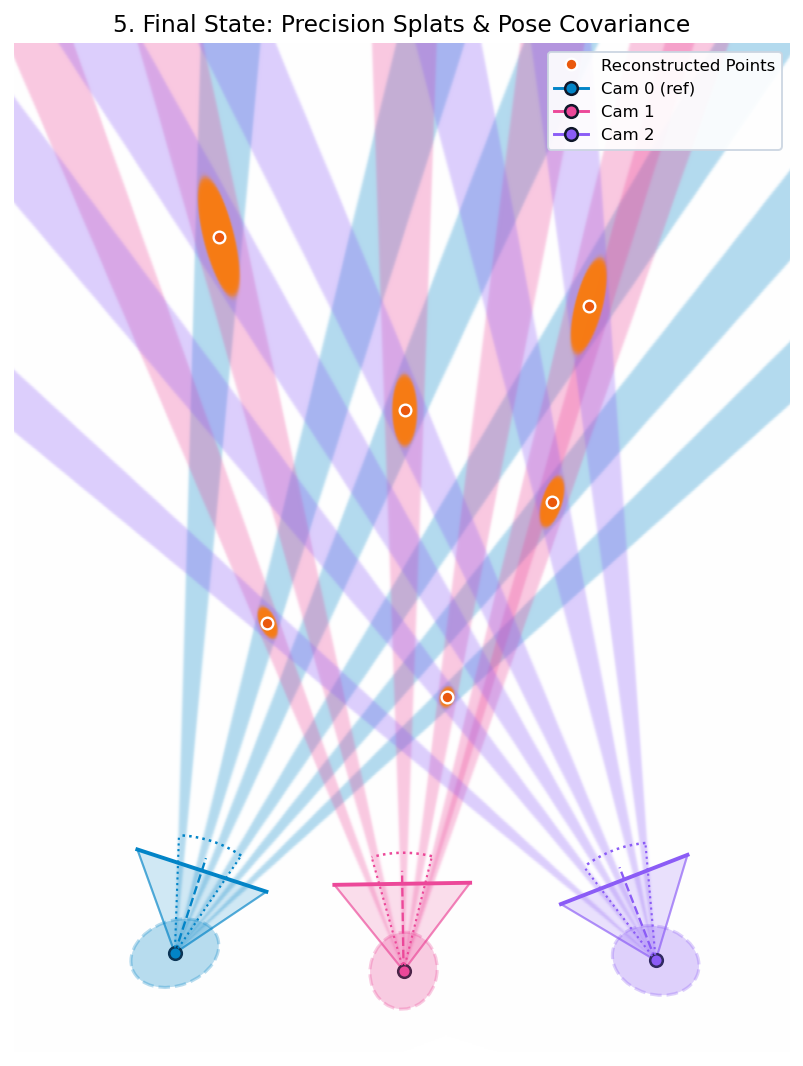


=== Reconstruction Accuracy Progression ===
1. Pre-optimization (perturbed Cam 2): 11.267 cm
2. Converged Landmark RMSE           : 11.116 cm
Camera 2 Positional 1-sigma uncertainty: [x: 153.386 cm, y: 163.137 cm]
Camera 2 Orientation 1-sigma uncertainty: 46.370 deg


In [7]:
# 1. The accumulated curvature is the information form on each camera's pose:
information: Information = curvature                        # [n_cams] Scalar <- (Twist, Twist)

# 2. Render final reconstructed state, moving the sight cones to the optimized camera poses:
opt_world_cones_final = opt_poses_alt >> cones(opt_poses_alt << Point)
fig = render.draw_reconstruction_with_covariance(
    opt_poses_alt, opt_world_cones_final, opt_splats_alt, opt_points_alt, information,
)
plt.title("5. Final State: Precision Splats & Pose Covariance")
plt.show()

print("\n=== Reconstruction Accuracy Progression ===")
print(f"1. Pre-optimization (perturbed Cam 2): {(init_rmse * 100).to_array():.3f} cm")
print(f"2. Converged Landmark RMSE           : {(alt_rmse * 100).to_array():.3f} cm")

# Camera 2 position and angular uncertainty, read out from the information form by the renderer:
sigma = render.pose_sigmas(information)                     # [n_cams, 3] one-sigma over (yw, wx, xy)
print(f"Camera 2 Positional 1-sigma uncertainty: [x: {sigma[2, 0] * 100:.3f} cm, y: {sigma[2, 1] * 100:.3f} cm]")
print(f"Camera 2 Orientation 1-sigma uncertainty: {np.degrees(sigma[2, 2]):.3f} deg")


## 6. Summary & Conceptual Synthesis

Having walked through the working pipeline, we can step back and examine how **extensors** structure the multi-view geometry:

* **Lifting Pixels into Sight Cones**:
  A pixel's precision disc is a polarity map on sensor points, `normal * (normal & Point)`. The map on lines induced by the camera, `(Plane & Point).solve(Plane & projection)`, carries the disc's polar lines back through the camera: `on_lines(sensor_discs(projection))` is a sight cone on scene points whose uncertainty widens with depth. It exists although the camera is singular, and no transpose is written.

* **Moving Quadrics Between Frames**:
  A multivector moves by one sandwich, `pose >> point`. A polarity map moves like any map, `pose >> cones(pose << Point)`: the point is pulled into the camera's frame and the polar line pushed out.

* **Combining Camera Views by Addition**:
  Quadrics are quadratic costs, so constraints from convergent viewpoints add, `world_cones.sum(axis=-1)`, fusing cones into localized confidence ellipsoids (splats).

* **Finding Vertices in Closed Form**:
  A fused cone's polar of its own vertex vanishes. A gauge dyad on the weight makes the vertex the pole of the line at infinity, and `splats.solve(w)` extracts it without ray-intersection heuristics.

* **Aligning Cameras by Newton's Method on the Cone Value**:
  The cost is a point's polar joined with the point. The motion of a local point under a pose twist, `-Twist.commutator(local_points)`, joined with its own polar is the curvature, and joined with the point's polar the gradient. The cone is the cost, so no residual metric is chosen.

* **Mapping Camera Uncertainty**:
  That curvature is the information on the pose. Its inverse on readouts gives the 1-sigma positional ellipses and angular heading fans.
